# V3.4 — Canopy generation & phyllotaxis  **TIER 3 / the foliage**

**Claim (pre-registered).** The canopy operator (`nebula.operators.canopy`) deposits leaves on the grown twigs by spiral phyllotaxis at the golden angle ψ=137.5°, producing a canopy with a plausible leaf-area-index, spread through the crown, deterministically — foliage **derived** from the skeleton + a phyllotactic rule, not authored. Each leaf is also a fine-fuel element (mass/moisture/char) for the crown flash (V3.5).

**Why load-bearing.** Blocker #4: Phase-0 was a bare skeleton — a tree's dominant visual mass is its canopy, and a leafless 'tree on fire' has nothing to flash. The golden angle is not decoration: it is the arrangement that packs leaves most evenly for light capture, so getting it right is what makes the canopy read as real foliage.

**Independent oracle.** `phyllotaxis_ref.py` — the golden angle 360°(2−φ), Vogel's spiral, and the packing-uniformity measure (golden minimises nearest-neighbour-distance variance vs nearby non-golden controls). No tree code.

**Pre-registered pass criteria (frozen below measured margins):**

| # | Metric | Threshold |
|---|---|---|
| C1 | canopy generated: leaf count | > 1000 leaves |
| C2 | phyllotaxis: median within-twig divergence angle | within 1.0° of golden (137.51°) |
| C3 | **golden packs evenly**: angular-gap CV (golden) vs (90° control) | golden < control |
| C4 | leaf-area-index (broadleaf canopy) | 2.0 ≤ LAI ≤ 8.0 |
| C5 | crown fill: fraction of height-bands with leaves | ≥ 0.6 |
| C6 | determinism: identical regeneration | bit-identical |

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
ROOT = pathlib.Path.cwd().resolve()
while ROOT.name and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src' / 'implementation'))
sys.path.insert(0, str(ROOT / 'src' / 'verification' / 'oracles'))
from nebula.operators.growth import grow_tree, GrowthParams
from nebula.operators import canopy as cano
import phyllotaxis_ref as ph
np.seterr(all='ignore')
tree = grow_tree(seed=7, gp=GrowthParams(dim=3))
can = cano.generate_canopy(tree, cano.CanopyParams(), seed=7)
R = {}
print(f'tree {tree.n} nodes -> canopy {can.n} leaves on {len(np.unique(can.twig_node))} twigs')

Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


tree 4418 nodes -> canopy 22764 leaves on 3794 twigs


In [2]:
R['C1_leaves'] = can.n
div = cano.divergence_angles_deg(can); R['C2_div'] = float(np.median(div))
gold = ph.folded_to_180(ph.GOLDEN_ANGLE_DEG)
u_g = cano.angular_uniformity(can)
u_c = cano.angular_uniformity(cano.generate_canopy(tree, cano.CanopyParams(angle_deg=90.0), seed=7))
R['C3_gold'], R['C3_ctrl'] = u_g, u_c
R['C4_lai'] = cano.leaf_area_index(can, tree)
R['C5_fill'] = cano.crown_fill(can, tree)
R['C6_det'] = bool(np.array_equal(can.pos, cano.generate_canopy(tree, cano.CanopyParams(), seed=7).pos))
print(f"C1 leaves {R['C1_leaves']}")
print(f"C2 median divergence {R['C2_div']:.2f}° (golden {gold:.2f}°)")
print(f"C3 angular-gap CV golden {u_g:.3f} < control {u_c:.3f}: {u_g < u_c}")
print(f"C4 LAI {R['C4_lai']:.2f} (2..8)")
print(f"C5 crown fill {R['C5_fill']:.2f} (>=0.6)")
print(f"C6 determinism {R['C6_det']}")

C1 leaves 22764
C2 median divergence 137.50° (golden 137.51°)
C3 angular-gap CV golden 0.320 < control 0.681: True
C4 LAI 5.48 (2..8)
C5 crown fill 0.88 (>=0.6)
C6 determinism True


saved results/V3_4_canopy.png

V3.4 PASS — the tree has a real, phyllotactic, combustible canopy.


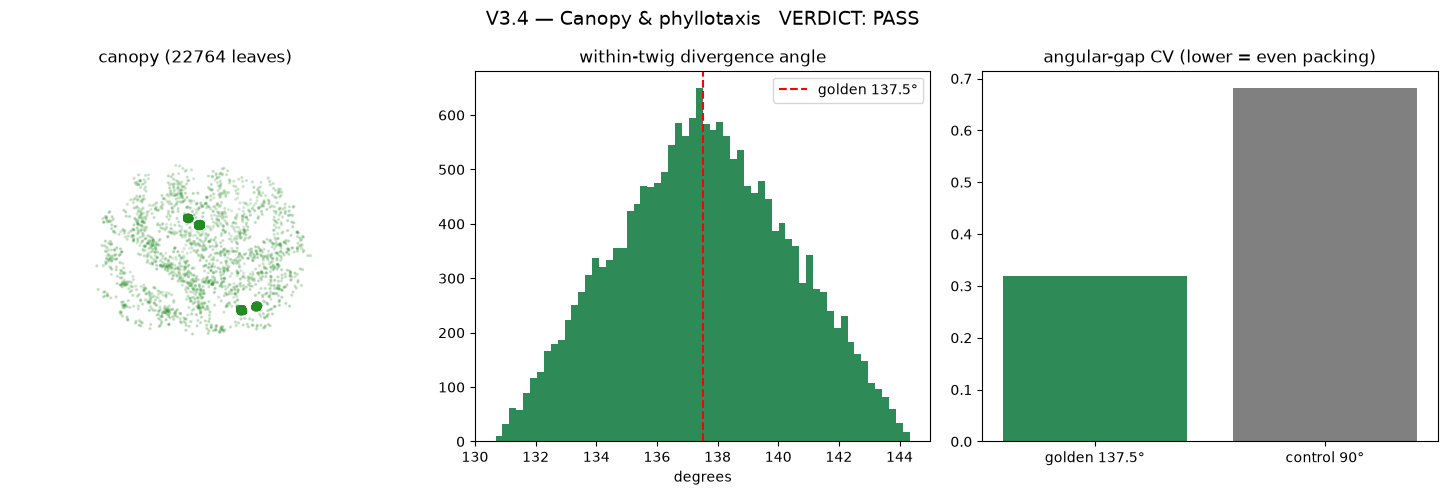

In [3]:
fig = plt.figure(figsize=(15, 5))
ax0 = fig.add_subplot(131, projection='3d')
s = np.random.default_rng(0).permutation(can.n)[:6000]
ax0.scatter(can.pos[s,0], can.pos[s,1], can.pos[s,2], c='forestgreen', s=2, alpha=0.5)
ax0.plot([], []); ax0.set_title(f'canopy ({can.n} leaves)'); ax0.set_axis_off()
ax1 = fig.add_subplot(132)
ax1.hist(div, bins=60, color='seagreen'); ax1.axvline(gold, color='r', ls='--', label=f'golden {gold:.1f}°')
ax1.set_title('within-twig divergence angle'); ax1.set_xlabel('degrees'); ax1.legend()
ax2 = fig.add_subplot(133)
ax2.bar(['golden 137.5°','control 90°'], [u_g, u_c], color=['seagreen','gray'])
ax2.set_title('angular-gap CV (lower = even packing)')
C1=R['C1_leaves']>1000; C2=abs(R['C2_div']-gold)<1.0; C3=R['C3_gold']<R['C3_ctrl']
C4=2.0<=R['C4_lai']<=8.0; C5=R['C5_fill']>=0.6; C6=R['C6_det']
allpass=C1 and C2 and C3 and C4 and C5 and C6
fig.suptitle(f'V3.4 — Canopy & phyllotaxis   VERDICT: {"PASS" if allpass else "FAIL"}', fontsize=14)
fig.tight_layout(); fig.savefig('results/V3_4_canopy.png', dpi=110, bbox_inches='tight')
print('saved results/V3_4_canopy.png')
assert allpass, 'V3.4 criteria not all met'
print('\nV3.4 PASS — the tree has a real, phyllotactic, combustible canopy.')